# 프로젝트 3: 설비관리 - 예지보전 & 센서 이상탐지

## 프로젝트 배경

당신은 **한국정밀산업(주)** 설비기술팀의 데이터 분석가입니다.  
최근 설비 고장이 연이어 발생하면서 경영진이 **예지보전(Predictive Maintenance)** 시스템 도입을 검토 중입니다.

> *"지난 4월에 EQ-A03 밀링머신이 베어링 고장으로 48시간 정지했고,  
> 5월에는 EQ-C02 CNC선반이 과열로 비상정지했습니다.  
> 센서 데이터를 분석하면 고장을 미리 예측할 수 있을까요?  
> 고장 전에 어떤 징후가 있었는지 분석해 주세요."*

### 분석 목표
1. **센서 데이터 탐색** - 12대 설비의 온도·진동·전류·압력 패턴 파악
2. **이상치 탐지** - 통계적 방법(3-sigma, IQR, 이동평균)으로 이상 신호 탐지
3. **고장 전조 분석** - 고장 발생 전 센서 데이터 변화 패턴 추적
4. **정비 이력 연계** - 정비/고장 이력과 센서 데이터 상관관계 분석
5. **설비 건강도 스코어링** - 설비 상태를 점수화하여 우선순위 도출

### 데이터 설명

| 파일 | 설명 | 주요 컬럼 |
|------|------|----------|
| `p3_equipment.csv` | 설비 마스터 (12대) | equipment_id, cumulative_hours, pm_cycle_days, criticality |
| `p3_sensor_log.csv` | 센서 시계열 (~21,000건, 2시간 주기) | timestamp, temperature_c, vibration_mms, current_a, pressure_bar |
| `p3_maintenance_log.csv` | 정비/고장 이력 (~230건) | maintenance_type(PM/CM/BM/INS), cause, duration_hours, cost_won |
| `p3_alarm_log.csv` | 설비 알람 기록 (~130건) | alarm_type, severity(경고/위험/긴급), acknowledged |

### 정비 유형

| 코드 | 유형 | 설명 |
|------|------|------|
| PM | 예방정비 | 계획된 정기 정비 |
| CM | 고장수리 | 설비 고장 후 수리 |
| BM | 사후보전 | 소규모 사후 조치 |
| INS | 점검 | 일상/주간 점검 |

### 예지보전의 핵심 개념

```
고장 발생 패턴:
  정상 운전 → 초기 징후(미세 변화) → 악화(명확한 이상) → 고장 발생

탐지 방법:
  1. 임계값 기반: 센서값 > 기준치 → 알람
  2. 통계적 방법: 이동평균/표준편차 벗어남 → 이상
  3. 추세 분석: 시간에 따른 변화율 증가 → 열화 진행
```

---

## Part 0: 환경 설정 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

equip = pd.read_csv('../data/project3/p3_equipment.csv', encoding='utf-8-sig')
sensor = pd.read_csv('../data/project3/p3_sensor_log.csv', encoding='utf-8-sig')
maint = pd.read_csv('../data/project3/p3_maintenance_log.csv', encoding='utf-8-sig')
alarm = pd.read_csv('../data/project3/p3_alarm_log.csv', encoding='utf-8-sig')

sensor['timestamp'] = pd.to_datetime(sensor['timestamp'])
maint['date'] = pd.to_datetime(maint['date'])
alarm['timestamp'] = pd.to_datetime(alarm['timestamp'])

print('데이터 로드 완료!')
print(f'설비: {len(equip)}건 | 센서: {len(sensor):,}건 | 정비: {len(maint)}건 | 알람: {len(alarm)}건')

데이터 로드 완료!
설비: 12건 | 센서: 21,750건 | 정비: 230건 | 알람: 132건


---
## Part 1: 데이터 탐색 및 전처리 (15점)

센서 데이터는 2시간 간격으로 수집되며, 센서 오류/통신 장애로 결측치가 포함됩니다.  
시계열 데이터에서의 결측치는 **보간(interpolation)**으로 처리하는 것이 일반적입니다.

### 문제 1-1: 데이터 탐색 (5점)

1. 4개 데이터프레임의 기본 정보(shape, dtypes)를 확인하세요
2. `sensor` 데이터의 결측치 현황을 컬럼별로 확인하세요
3. `sensor` 데이터의 기간(시작~끝), 설비별 건수를 확인하세요
4. `maint` 데이터의 정비 유형별 건수를 확인하세요
5. `equip` 테이블에서 설비별 누적가동시간과 중요도(criticality)를 확인하세요

In [2]:
# 여기에 코드 작성
equip.head(3)

,equipment_id,equipment_name,line,equipment_type,install_date,cumulative_hours,pm_cycle_days,last_pm_date,criticality
0,EQ-A01,CNC선반-A1,A라인,CNC선반,2018-03-15,12500,90,2024-01-15,A
1,EQ-A02,CNC선반-A2,A라인,CNC선반,2018-06-20,12100,90,2024-02-01,B
2,EQ-A03,밀링머신-A3,A라인,밀링머신,2019-01-10,10800,60,2024-01-20,A


In [3]:
sensor.head(3)

,sensor_id,timestamp,equipment_id,temperature_c,vibration_mms,current_a,pressure_bar
0,S-000001,2024-01-01,EQ-A01,40.3,2.19,15.8,4.75
1,S-000002,2024-01-01,EQ-A02,43.6,2.36,13.5,4.83
2,S-000003,2024-01-01,EQ-A03,43.7,3.02,16.0,4.85


In [4]:
maint.head(3)

,maintenance_id,date,equipment_id,maintenance_type,description,cause,duration_hours,cost_won,parts_replaced,technician_id
0,MT-00001,2024-01-01,EQ-A02,INS,주간점검 - 일상점검,일상점검,1.0,14000,NaN,TECH-08
1,MT-00002,2024-01-01,EQ-B01,INS,주간점검 - 진동측정,진동측정,1.0,24000,NaN,TECH-01
2,MT-00003,2024-01-01,EQ-C01,INS,주간점검 - 온도측정,온도측정,2.0,42000,NaN,TECH-07


In [5]:
alarm.head(3)

,alarm_id,timestamp,equipment_id,alarm_type,alarm_value,threshold,severity,acknowledged,resolved
0,ALM-00001,2024-01-02 06:00:00,EQ-A03,CRITICAL_VIBRATION,9.10,8.0,위험,False,False
1,ALM-00002,2024-01-02 08:00:00,EQ-A02,CRITICAL_VIBRATION,9.38,8.0,위험,True,True
2,ALM-00003,2024-01-04 00:00:00,EQ-B03,HIGH_VIBRATION,6.05,5.0,경고,True,True


In [6]:
sensor.shape

(21750, 7)

In [7]:
sensor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21750 entries, 0 to 21749
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   sensor_id      21750 non-null  object        
 1   timestamp      21750 non-null  datetime64[ns]
 2   equipment_id   21750 non-null  object        
 3   temperature_c  21315 non-null  float64       
 4   vibration_mms  21044 non-null  float64       
 5   current_a      21517 non-null  float64       
 6   pressure_bar   21558 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 1.2+ MB


In [8]:
sensor.head(3)

,sensor_id,timestamp,equipment_id,temperature_c,vibration_mms,current_a,pressure_bar
0,S-000001,2024-01-01,EQ-A01,40.3,2.19,15.8,4.75
1,S-000002,2024-01-01,EQ-A02,43.6,2.36,13.5,4.83
2,S-000003,2024-01-01,EQ-A03,43.7,3.02,16.0,4.85


In [9]:
sensor[sensor['sensor_id'].isna()]

,sensor_id,timestamp,equipment_id,temperature_c,vibration_mms,current_a,pressure_bar


In [10]:
sensor[sensor['timestamp'].isna()]

,sensor_id,timestamp,equipment_id,temperature_c,vibration_mms,current_a,pressure_bar


In [11]:
sensor[sensor['equipment_id'].isna()]

,sensor_id,timestamp,equipment_id,temperature_c,vibration_mms,current_a,pressure_bar


In [12]:
sensor[sensor['temperature_c'].isna()]

,sensor_id,timestamp,equipment_id,temperature_c,vibration_mms,current_a,pressure_bar
40,S-000041,2024-01-01 06:00:00,EQ-B02,NaN,0.96,13.2,5.05
167,S-000168,2024-01-02 04:00:00,EQ-B03,NaN,2.23,13.3,5.30
168,S-000169,2024-01-02 04:00:00,EQ-B04,NaN,1.05,11.5,5.66
216,S-000217,2024-01-02 12:00:00,EQ-C01,NaN,2.37,14.9,5.00
311,S-000312,2024-01-03 06:00:00,EQ-A01,NaN,NaN,15.1,4.85
...,...,...,...,...,...,...,...
21383,S-021384,2024-06-27 08:00:00,EQ-B02,NaN,1.24,13.7,5.31
21399,S-021400,2024-06-27 10:00:00,EQ-C02,NaN,1.89,14.8,4.77
21475,S-021476,2024-06-28 00:00:00,EQ-A04,NaN,1.87,13.0,5.29
21567,S-021568,2024-06-28 16:00:00,EQ-A04,NaN,2.14,13.1,5.10


In [13]:
sensor[sensor['vibration_mms'].isna()]

,sensor_id,timestamp,equipment_id,temperature_c,vibration_mms,current_a,pressure_bar
22,S-000023,2024-01-01 02:00:00,EQ-C04,42.1,NaN,11.0,5.54
32,S-000033,2024-01-01 04:00:00,EQ-C02,43.5,NaN,15.1,4.79
90,S-000091,2024-01-01 14:00:00,EQ-C03,38.8,NaN,14.0,5.40
119,S-000120,2024-01-01 20:00:00,EQ-A04,40.0,NaN,10.4,5.44
121,S-000122,2024-01-01 20:00:00,EQ-B02,38.5,NaN,11.1,5.07
...,...,...,...,...,...,...,...
21533,S-021534,2024-06-28 10:00:00,EQ-B02,39.2,NaN,12.7,5.52
21577,S-021578,2024-06-28 18:00:00,EQ-A02,43.1,NaN,16.2,5.02
21611,S-021612,2024-06-29 00:00:00,EQ-A01,48.5,NaN,13.6,5.09
21740,S-021741,2024-06-29 22:00:00,EQ-A03,47.8,NaN,17.5,4.77


In [14]:
sensor[sensor['current_a'].isna()]

,sensor_id,timestamp,equipment_id,temperature_c,vibration_mms,current_a,pressure_bar
164,S-000165,2024-01-02 04:00:00,EQ-A04,42.3,1.83,NaN,4.92
302,S-000303,2024-01-03 04:00:00,EQ-A04,41.3,1.01,NaN,5.24
312,S-000313,2024-01-03 06:00:00,EQ-A02,42.2,1.98,NaN,5.02
326,S-000327,2024-01-03 08:00:00,EQ-B01,35.9,1.29,NaN,5.68
419,S-000420,2024-01-04 00:00:00,EQ-B03,40.9,6.05,NaN,5.46
...,...,...,...,...,...,...,...
21446,S-021447,2024-06-27 18:00:00,EQ-C03,41.6,1.57,NaN,5.16
21558,S-021559,2024-06-28 14:00:00,EQ-B03,40.9,1.47,NaN,5.12
21580,S-021581,2024-06-28 18:00:00,EQ-B01,38.9,1.49,NaN,5.78
21607,S-021608,2024-06-28 22:00:00,EQ-C01,40.4,1.74,NaN,4.78


In [15]:
sensor[sensor['pressure_bar'].isna()]

,sensor_id,timestamp,equipment_id,temperature_c,vibration_mms,current_a,pressure_bar
52,S-000053,2024-01-01 08:00:00,EQ-B03,37.9,1.08,14.2,NaN
117,S-000118,2024-01-01 20:00:00,EQ-A02,41.1,2.16,14.5,NaN
274,S-000275,2024-01-02 22:00:00,EQ-C03,40.4,1.70,13.9,NaN
353,S-000354,2024-01-03 12:00:00,EQ-C02,41.7,2.39,11.6,NaN
444,S-000445,2024-01-04 04:00:00,EQ-C01,37.8,1.35,13.9,NaN
...,...,...,...,...,...,...,...
21336,S-021337,2024-06-27 00:00:00,EQ-B02,41.4,1.11,13.4,NaN
21344,S-021345,2024-06-27 02:00:00,EQ-A02,43.7,1.84,14.0,NaN
21454,S-021455,2024-06-27 20:00:00,EQ-B03,41.6,1.52,14.2,NaN
21647,S-021648,2024-06-29 06:00:00,EQ-A02,42.7,3.00,16.3,NaN


In [16]:
sensor.isna().sum()

sensor_id          0
timestamp          0
equipment_id       0
temperature_c    435
vibration_mms    706
current_a        233
pressure_bar     192
dtype: int64

In [17]:
sensor['timestamp'].min() ## 날짜 데이터의 최솟값

Timestamp('2024-01-01 00:00:00')

In [18]:
sensor['timestamp'].max()

Timestamp('2024-06-29 22:00:00')

In [19]:
sensor['equipment_id'].value_counts() ## value_counts하면 각 밸류별 갯수를 한눈에 확인할 수 있다.   

equipment_id
EQ-B01    1829
EQ-A02    1827
EQ-C01    1827
EQ-B04    1826
EQ-C04    1826
EQ-B02    1818
EQ-A04    1816
EQ-B03    1815
EQ-C03    1800
EQ-A01    1797
EQ-C02    1786
EQ-A03    1783
Name: count, dtype: int64

In [20]:
maint.head(3)

,maintenance_id,date,equipment_id,maintenance_type,description,cause,duration_hours,cost_won,parts_replaced,technician_id
0,MT-00001,2024-01-01,EQ-A02,INS,주간점검 - 일상점검,일상점검,1.0,14000,NaN,TECH-08
1,MT-00002,2024-01-01,EQ-B01,INS,주간점검 - 진동측정,진동측정,1.0,24000,NaN,TECH-01
2,MT-00003,2024-01-01,EQ-C01,INS,주간점검 - 온도측정,온도측정,2.0,42000,NaN,TECH-07


In [21]:
maint['maintenance_type'].value_counts()

maintenance_type
INS    166
BM      30
PM      19
CM      15
Name: count, dtype: int64

In [22]:
equip.head(3)

,equipment_id,equipment_name,line,equipment_type,install_date,cumulative_hours,pm_cycle_days,last_pm_date,criticality
0,EQ-A01,CNC선반-A1,A라인,CNC선반,2018-03-15,12500,90,2024-01-15,A
1,EQ-A02,CNC선반-A2,A라인,CNC선반,2018-06-20,12100,90,2024-02-01,B
2,EQ-A03,밀링머신-A3,A라인,밀링머신,2019-01-10,10800,60,2024-01-20,A


In [23]:
equip.columns

Index(['equipment_id', 'equipment_name', 'line', 'equipment_type',
       'install_date', 'cumulative_hours', 'pm_cycle_days', 'last_pm_date',
       'criticality'],
      dtype='object')

In [24]:
equip[['equipment_id', 'equipment_name', 'line','cumulative_hours','criticality']]

,equipment_id,equipment_name,line,cumulative_hours,criticality
0,EQ-A01,CNC선반-A1,A라인,12500,A
1,EQ-A02,CNC선반-A2,A라인,12100,B
2,EQ-A03,밀링머신-A3,A라인,10800,A
3,EQ-A04,드릴프레스-A4,A라인,10200,C
4,EQ-B01,CNC선반-B1,B라인,5800,B
5,EQ-B02,CNC선반-B2,B라인,5500,B
6,EQ-B03,밀링머신-B3,B라인,4200,A
7,EQ-B04,드릴프레스-B4,B라인,3900,C
8,EQ-C01,CNC선반-C1,C라인,8500,B
9,EQ-C02,CNC선반-C2,C라인,8200,A


### 문제 1-2: 센서 데이터 결측치 처리 (5점)

시계열 센서 데이터의 결측치는 **설비별 시간순 보간**이 가장 적합합니다.

1. 설비별로 그룹화한 후, 수치형 컬럼의 결측치를 **선형 보간(interpolate)**으로 처리
2. 보간 후에도 남는 결측치(시작/끝 부분)는 **전방/후방 채움(ffill/bfill)**으로 처리
3. 처리 후 결측치가 0인지 확인

In [25]:
# 여기에 코드 작성
sensor.head()

,sensor_id,timestamp,equipment_id,temperature_c,vibration_mms,current_a,pressure_bar
0,S-000001,2024-01-01,EQ-A01,40.3,2.19,15.8,4.75
1,S-000002,2024-01-01,EQ-A02,43.6,2.36,13.5,4.83
2,S-000003,2024-01-01,EQ-A03,43.7,3.02,16.0,4.85
3,S-000004,2024-01-01,EQ-A04,41.5,2.04,12.1,5.21
4,S-000005,2024-01-01,EQ-B01,36.7,1.13,11.3,5.42


In [26]:
sensor=sensor.sort_values(['equipment_id','timestamp']).reset_index(drop=True)

In [27]:
sensor.columns

Index(['sensor_id', 'timestamp', 'equipment_id', 'temperature_c',
       'vibration_mms', 'current_a', 'pressure_bar'],
      dtype='object')

In [28]:
def trans(x) :
    return x.interpolate(mathod='linear')

In [29]:
sensor.groupby('equipment_id')[['temperature_c','vibration_mms', 'current_a', 'pressure_bar']].transform(trans)

,temperature_c,vibration_mms,current_a,pressure_bar
0,40.3,2.19,15.8,4.75
1,44.3,2.17,14.8,4.90
2,43.0,2.62,13.9,5.17
3,43.4,2.83,14.5,5.45
4,40.7,2.20,15.6,5.33
...,...,...,...,...
21745,38.9,1.53,11.2,5.32
21746,41.3,1.86,9.5,5.33
21747,39.1,2.33,12.8,5.15
21748,36.9,2.03,10.8,5.34


In [30]:
sensor[['temperature_c','vibration_mms', 'current_a', 'pressure_bar']] = sensor.groupby('equipment_id')[['temperature_c','vibration_mms', 'current_a', 'pressure_bar']].transform(trans)

In [31]:
sensor.isna().sum() # 이렇게 해도 nan이 있는 경우가 있다 왜냐하면 맨 앞과 맨뒤에는 interpolate가 안됨 그래서 앞의 데이터나 뒤의 데이터를 가져오면 됌

sensor_id        0
timestamp        0
equipment_id     0
temperature_c    0
vibration_mms    0
current_a        0
pressure_bar     0
dtype: int64

In [32]:
# 맨 윗행(맨 위 데이터) 또는 맨 아래행(맨 아래 데이터)가 비어있을 수 있다.
#ffill, bfill로 전체 nan을 없앤다.

In [33]:
cols=['temperature_c','vibration_mms', 'current_a', 'pressure_bar']

In [34]:
def tran2(x) :
    return x.ffill().bfill()

In [35]:
sensor.groupby('equipment_id')[cols].transform(tran2) #앞에 데이터랑 뒤에 데이터 결측치 해결하는 법

,temperature_c,vibration_mms,current_a,pressure_bar
0,40.3,2.19,15.8,4.75
1,44.3,2.17,14.8,4.90
2,43.0,2.62,13.9,5.17
3,43.4,2.83,14.5,5.45
4,40.7,2.20,15.6,5.33
...,...,...,...,...
21745,38.9,1.53,11.2,5.32
21746,41.3,1.86,9.5,5.33
21747,39.1,2.33,12.8,5.15
21748,36.9,2.03,10.8,5.34


### 문제 1-3: 파생 컬럼 및 정비 데이터 결합 (5점)

1. `sensor`에 파생 컬럼 추가:
   - `date` (날짜만)
   - `hour` (시간)
   - `month` (월)
   - `line` (설비ID에서 추출: A라인/B라인/C라인)

2. `maint`에서 `cause` 결측치를 `'원인미상'`으로 대체

3. `equip` 테이블의 `install_date`를 datetime으로 변환하고, **설비 나이(년)**를 계산하세요
   - 기준일: 2024-07-01

In [36]:
# 여기에 코드 작성
sensor.head(3)

,sensor_id,timestamp,equipment_id,temperature_c,vibration_mms,current_a,pressure_bar
0,S-000001,2024-01-01 00:00:00,EQ-A01,40.3,2.19,15.8,4.75
1,S-000012,2024-01-01 02:00:00,EQ-A01,44.3,2.17,14.8,4.90
2,S-000024,2024-01-01 04:00:00,EQ-A01,43.0,2.62,13.9,5.17


In [37]:
# pd.to_datetime()을 해줘야함
sensor['date']=sensor['timestamp'].dt.date

In [38]:
sensor['month']=sensor['timestamp'].dt.month

In [39]:
sensor['hour']=sensor['timestamp'].dt.hour

In [40]:
sensor.head(2)

,sensor_id,timestamp,equipment_id,temperature_c,vibration_mms,current_a,pressure_bar,date,month,hour
0,S-000001,2024-01-01 00:00:00,EQ-A01,40.3,2.19,15.8,4.75,2024-01-01,1,0
1,S-000012,2024-01-01 02:00:00,EQ-A01,44.3,2.17,14.8,4.90,2024-01-01,1,2


In [41]:
sensor['equipment_id'].unique()

array(['EQ-A01', 'EQ-A02', 'EQ-A03', 'EQ-A04', 'EQ-B01', 'EQ-B02',
       'EQ-B03', 'EQ-B04', 'EQ-C01', 'EQ-C02', 'EQ-C03', 'EQ-C04'],
      dtype=object)

In [42]:
def get_line(x) :
    if 'A' in x :
        return 'A라인'
    elif 'B' in x :
        return 'B라인'
    elif 'C' in x :
        return 'C라인'

In [43]:
sensor['equipment_id'].apply(get_line)

0        A라인
1        A라인
2        A라인
3        A라인
4        A라인
        ... 
21745    C라인
21746    C라인
21747    C라인
21748    C라인
21749    C라인
Name: equipment_id, Length: 21750, dtype: object

In [44]:
sensor['line']=sensor['equipment_id'].apply(get_line)

In [45]:
sensor['equipment_id'].str.contains('C')

0        False
1        False
2        False
3        False
4        False
         ...  
21745     True
21746     True
21747     True
21748     True
21749     True
Name: equipment_id, Length: 21750, dtype: bool

In [46]:
maint['cause'].fillna('원인미상', inplace=True)

In [47]:
maint.isna().sum()

maintenance_id        0
date                  0
equipment_id          0
maintenance_type      0
description           0
cause                 0
duration_hours        1
cost_won              0
parts_replaced      174
technician_id         0
dtype: int64

In [48]:
equip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   equipment_id      12 non-null     object
 1   equipment_name    12 non-null     object
 2   line              12 non-null     object
 3   equipment_type    12 non-null     object
 4   install_date      12 non-null     object
 5   cumulative_hours  12 non-null     int64 
 6   pm_cycle_days     12 non-null     int64 
 7   last_pm_date      12 non-null     object
 8   criticality       12 non-null     object
dtypes: int64(2), object(7)
memory usage: 992.0+ bytes


In [49]:
equip['install_date']=pd.to_datetime(equip['install_date'])

In [50]:
equip['install_date']

0    2018-03-15
1    2018-06-20
2    2019-01-10
3    2019-04-05
4    2021-07-01
5    2021-09-15
6    2022-02-10
7    2022-05-20
8    2020-01-15
9    2020-04-10
10   2020-08-25
11   2020-11-30
Name: install_date, dtype: datetime64[ns]

In [51]:
ref_date=pd.Timestamp('2024-07-01')

In [52]:
equip['age_years']=((ref_date-equip['install_date']).dt.days/365).round(1)

In [53]:
equip

,equipment_id,equipment_name,line,equipment_type,install_date,cumulative_hours,pm_cycle_days,last_pm_date,criticality,age_years
0,EQ-A01,CNC선반-A1,A라인,CNC선반,2018-03-15,12500,90,2024-01-15,A,6.3
1,EQ-A02,CNC선반-A2,A라인,CNC선반,2018-06-20,12100,90,2024-02-01,B,6.0
2,EQ-A03,밀링머신-A3,A라인,밀링머신,2019-01-10,10800,60,2024-01-20,A,5.5
3,EQ-A04,드릴프레스-A4,A라인,드릴프레스,2019-04-05,10200,120,2023-12-10,C,5.2
4,EQ-B01,CNC선반-B1,B라인,CNC선반,2021-07-01,5800,90,2024-02-15,B,3.0
5,EQ-B02,CNC선반-B2,B라인,CNC선반,2021-09-15,5500,90,2024-02-20,B,2.8
6,EQ-B03,밀링머신-B3,B라인,밀링머신,2022-02-10,4200,60,2024-03-01,A,2.4
7,EQ-B04,드릴프레스-B4,B라인,드릴프레스,2022-05-20,3900,120,2024-01-25,C,2.1
8,EQ-C01,CNC선반-C1,C라인,CNC선반,2020-01-15,8500,90,2024-01-10,B,4.5
9,EQ-C02,CNC선반-C2,C라인,CNC선반,2020-04-10,8200,90,2024-02-05,A,4.2


---
## Part 2: 센서 데이터 분석 & 이상탐지 (30점)

예지보전의 핵심은 **정상 패턴을 이해하고, 이상을 탐지하는 것**입니다.  
먼저 설비별 센서 데이터의 정상 범위를 파악하고,  
여러 통계적 방법으로 이상 신호를 탐지합니다.

### 문제 2-1: 설비별 센서 기본 통계 (5점)

1. 설비별 4개 센서(온도, 진동, 전류, 압력)의 평균·표준편차·최소·최대를 집계하세요
2. **설비별 평균 온도**를 수평 막대 차트로 시각화 (라인별 색상 구분)
3. **설비별 평균 진동**도 같은 방식으로 시각화
4. 어떤 설비가 센서값이 가장 높은가? (온도, 진동 각각)

In [54]:
sensor.head(3)

,sensor_id,timestamp,equipment_id,temperature_c,vibration_mms,current_a,pressure_bar,date,month,hour,line
0,S-000001,2024-01-01 00:00:00,EQ-A01,40.3,2.19,15.8,4.75,2024-01-01,1,0,A라인
1,S-000012,2024-01-01 02:00:00,EQ-A01,44.3,2.17,14.8,4.90,2024-01-01,1,2,A라인
2,S-000024,2024-01-01 04:00:00,EQ-A01,43.0,2.62,13.9,5.17,2024-01-01,1,4,A라인


In [55]:
sensor.columns

Index(['sensor_id', 'timestamp', 'equipment_id', 'temperature_c',
       'vibration_mms', 'current_a', 'pressure_bar', 'date', 'month', 'hour',
       'line'],
      dtype='object')

In [56]:
cols = ['temperature_c',
       'vibration_mms', 'current_a', 'pressure_bar']

In [57]:
# 여기에 코드 작성
stats=sensor.groupby('equipment_id')[cols].agg(['mean','std','min','max']) #agg에 함수만 넣어주는 형태

In [58]:
equip_means=sensor.groupby('equipment_id')[['temperature_c','vibration_mms']].mean()

In [59]:
equip_means

,temperature_c,vibration_mms
equipment_id,,
EQ-A01,43.490150,2.573659
EQ-A02,42.583415,2.407904
EQ-A03,45.494139,3.144274
EQ-A04,41.693365,1.919813
EQ-B01,37.277283,1.169161
EQ-B02,38.439191,1.314706
EQ-B03,39.480716,1.515667
EQ-B04,37.397755,1.142848
EQ-C01,40.671593,1.866907


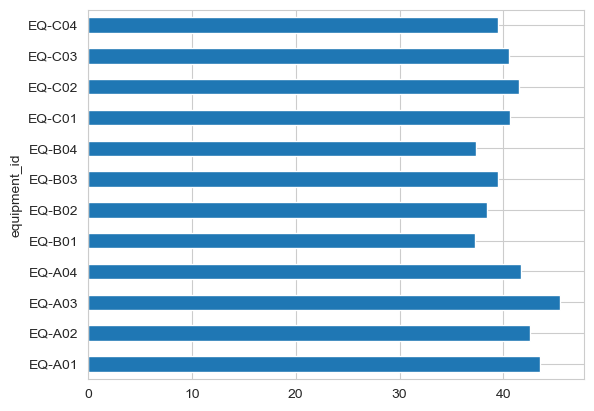

In [60]:
equip_means['temperature_c'].plot(kind='barh' )
plt.show()

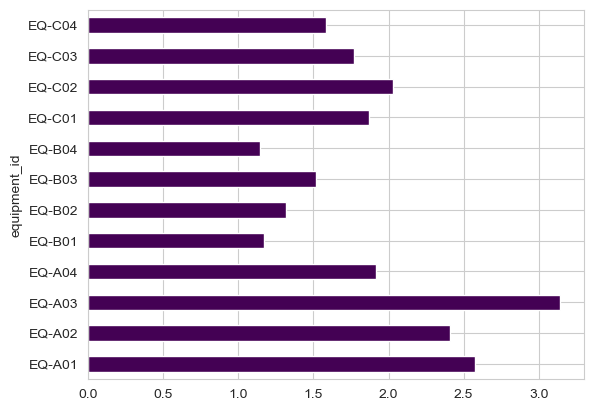

In [61]:
equip_means['vibration_mms'].plot(kind='barh', colormap='viridis' )
plt.show()

In [62]:
equip_means['temperature_c'].idxmax()

'EQ-A03'

In [63]:
equip_means['vibration_mms'].idxmax()

'EQ-A03'

### 문제 2-2: 센서 시계열 시각화 (5점)

**고장이 발생한 3대 설비(EQ-A03, EQ-C02, EQ-A01)**의 센서 데이터를 시계열로 시각화하세요.

1. 3개 설비 × 2개 센서(온도, 진동) = **3행 2열 서브플롯** (Figure 18×12)
2. 각 차트에 일별 이동평균(7일)도 함께 표시 (빨간 실선)
3. 고장 발생일을 세로 점선으로 표시:
   - EQ-A03: 2024-04-15 (베어링 고장)
   - EQ-C02: 2024-05-20 (과열 정지)
   - EQ-A01: 2024-03-10 (전류 이상)
4. 고장 전 10일간 데이터에 배경색(빨간 음영)을 표시하세요

> **현업 포인트**: 시계열 차트에서 "고장 전에 서서히 올라가는 패턴"을 찾아보세요.

In [64]:
sensor

,sensor_id,timestamp,equipment_id,temperature_c,vibration_mms,current_a,pressure_bar,date,month,hour,line
0,S-000001,2024-01-01 00:00:00,EQ-A01,40.3,2.19,15.8,4.75,2024-01-01,1,0,A라인
1,S-000012,2024-01-01 02:00:00,EQ-A01,44.3,2.17,14.8,4.90,2024-01-01,1,2,A라인
2,S-000024,2024-01-01 04:00:00,EQ-A01,43.0,2.62,13.9,5.17,2024-01-01,1,4,A라인
3,S-000036,2024-01-01 06:00:00,EQ-A01,43.4,2.83,14.5,5.45,2024-01-01,1,6,A라인
4,S-000059,2024-01-01 10:00:00,EQ-A01,40.7,2.20,15.6,5.33,2024-01-01,1,10,A라인
...,...,...,...,...,...,...,...,...,...,...,...
21745,S-021703,2024-06-29 14:00:00,EQ-C04,38.9,1.53,11.2,5.32,2024-06-29,6,14,C라인
21746,S-021714,2024-06-29 16:00:00,EQ-C04,41.3,1.86,9.5,5.33,2024-06-29,6,16,C라인
21747,S-021726,2024-06-29 18:00:00,EQ-C04,39.1,2.33,12.8,5.15,2024-06-29,6,18,C라인
21748,S-021738,2024-06-29 20:00:00,EQ-C04,36.9,2.03,10.8,5.34,2024-06-29,6,20,C라인


In [65]:
sensor_a003=sensor[sensor['equipment_id']=='EQ-A03'].loc[:,['temperature_c','vibration_mms','timestamp']]

In [66]:
sensor_a003 = sensor_a003.set_index('timestamp')

In [67]:
sensor_a003

,temperature_c,vibration_mms
timestamp,,
2024-01-01 00:00:00,43.7,3.02
2024-01-01 02:00:00,45.1,3.54
2024-01-01 04:00:00,45.7,3.17
2024-01-01 06:00:00,47.5,2.75
2024-01-01 08:00:00,42.2,3.18
...,...,...
2024-06-29 12:00:00,47.1,3.77
2024-06-29 14:00:00,44.8,3.27
2024-06-29 18:00:00,45.5,3.52


In [68]:
sensor_a003['tem_7day_man']=sensor_a003['temperature_c'].rolling(window=84).mean()

In [69]:
sensor_a003['vib_7day_man']=sensor_a003['vibration_mms'].rolling(window=84).mean()

In [70]:
sensor_a003

,temperature_c,vibration_mms,tem_7day_man,vib_7day_man
timestamp,,,,
2024-01-01 00:00:00,43.7,3.02,NaN,NaN
2024-01-01 02:00:00,45.1,3.54,NaN,NaN
2024-01-01 04:00:00,45.7,3.17,NaN,NaN
2024-01-01 06:00:00,47.5,2.75,NaN,NaN
2024-01-01 08:00:00,42.2,3.18,NaN,NaN
...,...,...,...,...
2024-06-29 12:00:00,47.1,3.77,47.232738,3.175595
2024-06-29 14:00:00,44.8,3.27,47.237500,3.180476
2024-06-29 18:00:00,45.5,3.52,47.248214,3.186786


In [71]:
from koreanize_matplotlib import koreanize
koreanize()

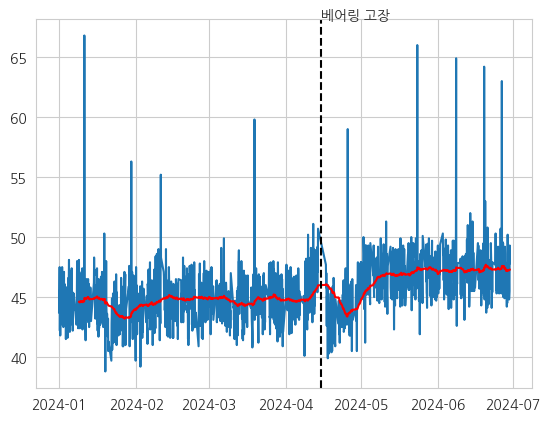

In [72]:
plt.plot(sensor_a003.index, sensor_a003['temperature_c'] )
plt.plot(sensor_a003.index, sensor_a003['tem_7day_man'] ,color='red')
plt.axvline(pd.to_datetime('2024-04-15'), color='black', linestyle='--')
y_pos = sensor_a003['temperature_c'].max() * 1.02
event_date = pd.to_datetime('2024-04-15')
plt.text(
    x=event_date,
    y=y_pos,
    s='베어링 고장',
    ha='left'
)
plt.show()

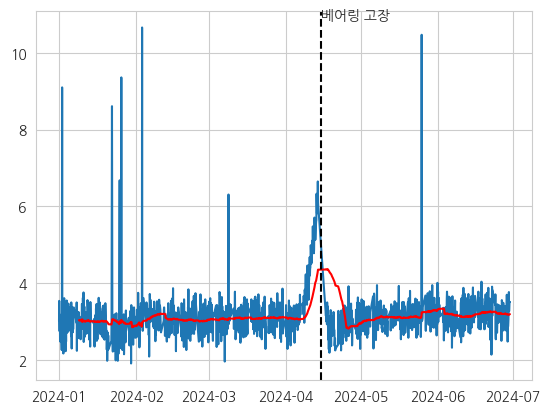

In [73]:
plt.plot(sensor_a003.index, sensor_a003['vibration_mms'] )
plt.plot(sensor_a003.index, sensor_a003['vib_7day_man'] ,color='red')
plt.axvline(pd.to_datetime('2024-04-15'), color='black', linestyle='--')
y_pos = sensor_a003['vibration_mms'].max() * 1.02
event_date = pd.to_datetime('2024-04-15')
plt.text(
    x=event_date,
    y=y_pos,
    s='베어링 고장',
    ha='left'
)
plt.show()

In [74]:
sensor_c02=sensor.loc[sensor['equipment_id']=='EQ-C02',['temperature_c','vibration_mms','timestamp']]

In [75]:
sensor_c02 = sensor_c02.set_index('timestamp')
sensor_c02['tem_7day_man']=sensor_c02['temperature_c'].rolling(window=84).mean()
sensor_c02['vib_7day_man']=sensor_c02['vibration_mms'].rolling(window=84).mean()

In [76]:
sensor_c02

,temperature_c,vibration_mms,tem_7day_man,vib_7day_man
timestamp,,,,
2024-01-01 00:00:00,40.9,1.740,NaN,NaN
2024-01-01 02:00:00,44.3,1.790,NaN,NaN
2024-01-01 04:00:00,43.5,1.705,NaN,NaN
2024-01-01 06:00:00,42.6,1.620,NaN,NaN
2024-01-01 08:00:00,37.8,2.040,NaN,NaN
...,...,...,...,...
2024-06-29 14:00:00,44.6,2.220,42.752381,2.074345
2024-06-29 16:00:00,41.2,2.010,42.750000,2.070893
2024-06-29 18:00:00,41.7,1.920,42.733333,2.076369


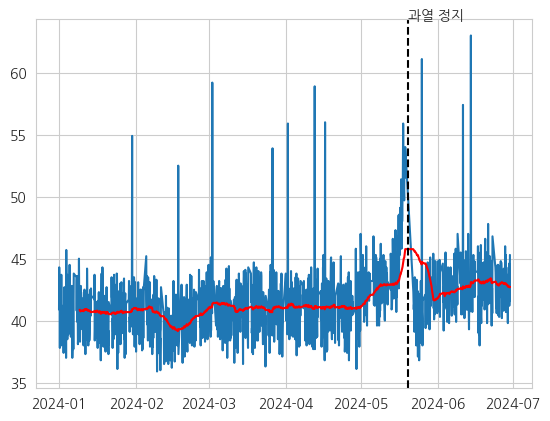

In [77]:
plt.plot(sensor_c02.index, sensor_c02['temperature_c'] )
plt.plot(sensor_c02.index, sensor_c02['tem_7day_man'] ,color='red')
plt.axvline(pd.to_datetime('2024-05-20'), color='black', linestyle='--')
y_pos = sensor_c02['temperature_c'].max() * 1.02
event_date = pd.to_datetime('2024-05-20')
plt.text(
    x=event_date,
    y=y_pos,
    s='과열 정지',
    ha='left'
)
plt.show()

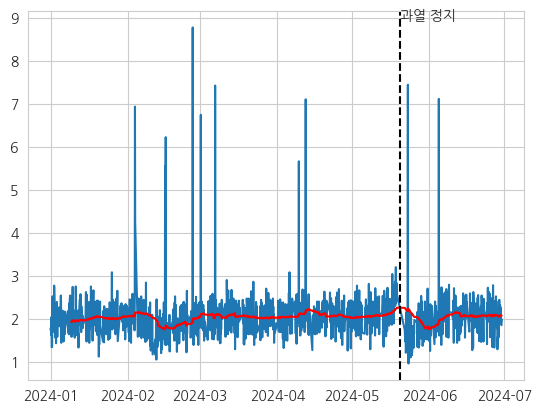

In [78]:
plt.plot(sensor_c02.index, sensor_c02['vibration_mms'] )
plt.plot(sensor_c02.index, sensor_c02['vib_7day_man'] ,color='red')
plt.axvline(pd.to_datetime('2024-05-20'), color='black', linestyle='--')
y_pos = sensor_c02['vibration_mms'].max() * 1.02
event_date = pd.to_datetime('2024-05-20')
plt.text(
    x=event_date,
    y=y_pos,
    s='과열 정지',
    ha='left'
)
plt.show()

In [79]:
sensor_a01=sensor.loc[sensor['equipment_id']=='EQ-A01',['temperature_c','vibration_mms','timestamp']]

In [80]:
sensor_a01

,temperature_c,vibration_mms,timestamp
0,40.3,2.19,2024-01-01 00:00:00
1,44.3,2.17,2024-01-01 02:00:00
2,43.0,2.62,2024-01-01 04:00:00
3,43.4,2.83,2024-01-01 06:00:00
4,40.7,2.20,2024-01-01 10:00:00
...,...,...,...
1792,43.2,2.76,2024-06-29 14:00:00
1793,44.3,2.70,2024-06-29 16:00:00
1794,43.1,2.30,2024-06-29 18:00:00
1795,45.0,2.32,2024-06-29 20:00:00


In [81]:
sensor_a01 = sensor_a01.set_index('timestamp')
sensor_a01['tem_7day_man']=sensor_a01['temperature_c'].rolling(window=84).mean()
sensor_a01['vib_7day_man']=sensor_a01['vibration_mms'].rolling(window=84).mean()

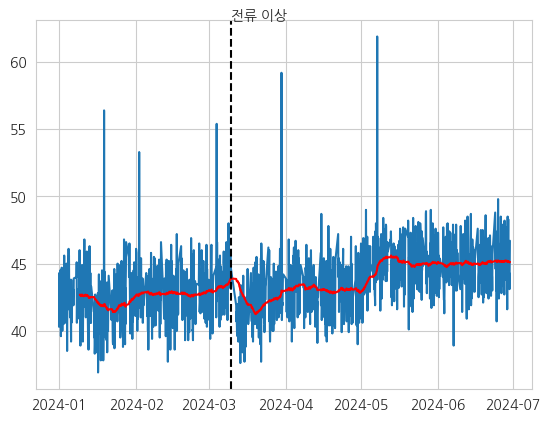

In [82]:
plt.plot(sensor_a01.index, sensor_a01['temperature_c'] )
plt.plot(sensor_a01.index, sensor_a01['tem_7day_man'] ,color='red')
plt.axvline(pd.to_datetime('2024-03-10'), color='black', linestyle='--')
y_pos = sensor_a01['temperature_c'].max() * 1.02
event_date = pd.to_datetime('2024-03-10')
plt.text(
    x=event_date,
    y=y_pos,
    s='전류 이상',
    ha='left'
)
plt.show()

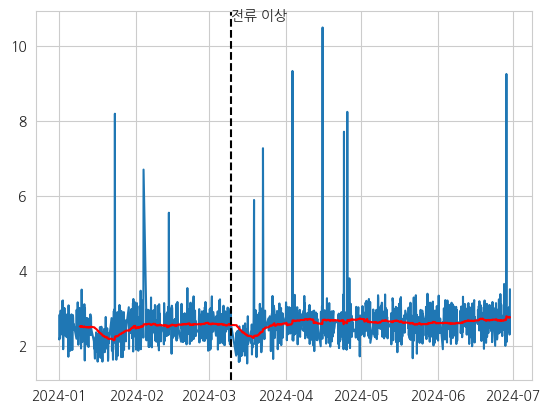

In [83]:
plt.plot(sensor_a01.index, sensor_a01['vibration_mms'] )
plt.plot(sensor_a01.index, sensor_a01['vib_7day_man'] ,color='red')
plt.axvline(pd.to_datetime('2024-03-10'), color='black', linestyle='--')
y_pos = sensor_a01['vibration_mms'].max() * 1.02
event_date = pd.to_datetime('2024-03-10')
plt.text(
    x=event_date,
    y=y_pos,
    s='전류 이상',
    ha='left'
)
plt.show()

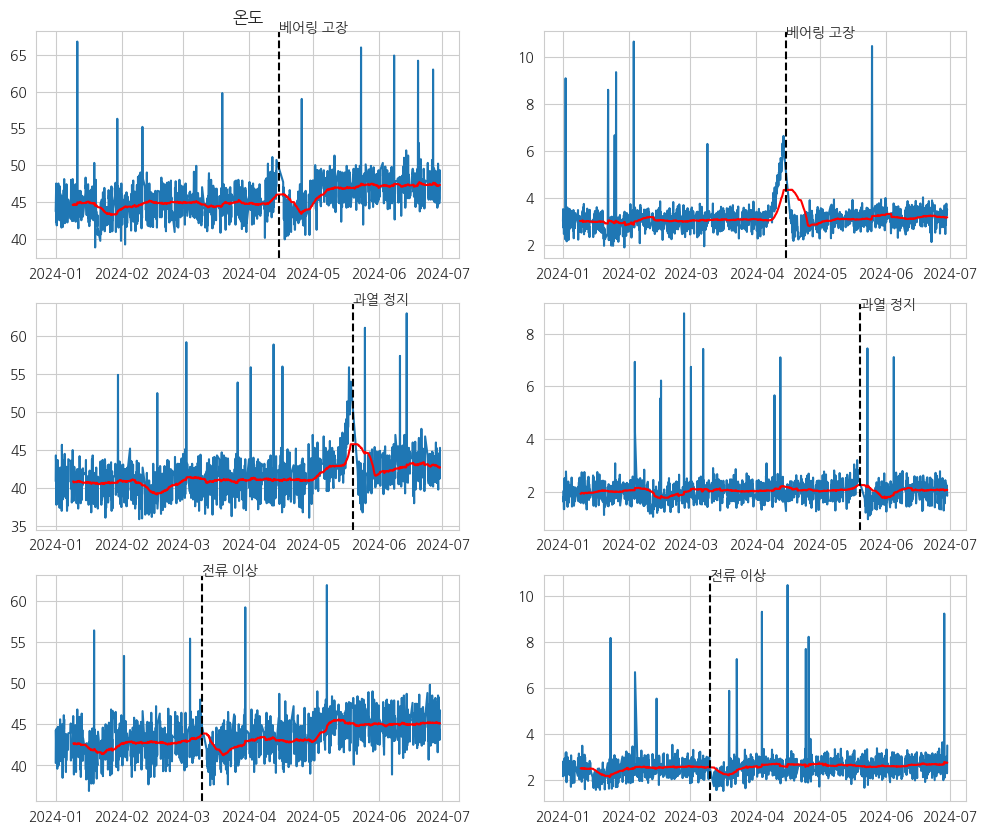

In [84]:
plt.figure(figsize=(12,10))
plt.subplot(3,2,1)
plt.plot(sensor_a003.index, sensor_a003['temperature_c'] )
plt.plot(sensor_a003.index, sensor_a003['tem_7day_man'] ,color='red')
plt.axvline(pd.to_datetime('2024-04-15'), color='black', linestyle='--')
y_pos = sensor_a003['temperature_c'].max() * 1.02
event_date = pd.to_datetime('2024-04-15')
plt.text(
    x=event_date,
    y=y_pos,
    s='베어링 고장',
    ha='left'
)
plt.title('온도')


plt.subplot(3,2,2)
plt.plot(sensor_a003.index, sensor_a003['vibration_mms'] )
plt.plot(sensor_a003.index, sensor_a003['vib_7day_man'] ,color='red')
plt.axvline(pd.to_datetime('2024-04-15'), color='black', linestyle='--')
y_pos = sensor_a003['vibration_mms'].max() * 1.02
event_date = pd.to_datetime('2024-04-15')
plt.text(
    x=event_date,
    y=y_pos,
    s='베어링 고장',
    ha='left'
)

plt.subplot(3,2,3)
plt.plot(sensor_c02.index, sensor_c02['temperature_c'] )
plt.plot(sensor_c02.index, sensor_c02['tem_7day_man'] ,color='red')
plt.axvline(pd.to_datetime('2024-05-20'), color='black', linestyle='--')
y_pos = sensor_c02['temperature_c'].max() * 1.02
event_date = pd.to_datetime('2024-05-20')
plt.text(
    x=event_date,
    y=y_pos,
    s='과열 정지',
    ha='left'
)

plt.subplot(3,2,4)
plt.plot(sensor_c02.index, sensor_c02['vibration_mms'] )
plt.plot(sensor_c02.index, sensor_c02['vib_7day_man'] ,color='red')
plt.axvline(pd.to_datetime('2024-05-20'), color='black', linestyle='--')
y_pos = sensor_c02['vibration_mms'].max() * 1.02
event_date = pd.to_datetime('2024-05-20')
plt.text(
    x=event_date,
    y=y_pos,
    s='과열 정지',
    ha='left'
)

plt.subplot(3,2,5)
plt.plot(sensor_a01.index, sensor_a01['temperature_c'] )
plt.plot(sensor_a01.index, sensor_a01['tem_7day_man'] ,color='red')
plt.axvline(pd.to_datetime('2024-03-10'), color='black', linestyle='--')
y_pos = sensor_a01['temperature_c'].max() * 1.02
event_date = pd.to_datetime('2024-03-10')
plt.text(
    x=event_date,
    y=y_pos,
    s='전류 이상',
    ha='left'
)

plt.subplot(3,2,6)
plt.plot(sensor_a01.index, sensor_a01['vibration_mms'] )
plt.plot(sensor_a01.index, sensor_a01['vib_7day_man'] ,color='red')
plt.axvline(pd.to_datetime('2024-03-10'), color='black', linestyle='--')
y_pos = sensor_a01['vibration_mms'].max() * 1.02
event_date = pd.to_datetime('2024-03-10')
plt.text(
    x=event_date,
    y=y_pos,
    s='전류 이상',
    ha='left'
)

plt.show()

### 문제 2-3: 3-Sigma 이상탐지 (10점)

가장 기본적인 이상탐지 방법입니다.  
평균 ± 3σ를 벗어나는 점을 이상으로 판정합니다.

1. **설비별**로 각 센서의 평균(μ)과 표준편차(σ)를 계산
2. `|x - μ| > 3σ`인 점을 이상치로 판정하여 `is_anomaly_temp`, `is_anomaly_vib` 컬럼 추가
3. 설비별 이상치 건수를 집계하세요
4. **EQ-A03의 진동 데이터**를 시계열로 그리고, 이상치를 빨간 점으로 표시하세요
   - μ ± 3σ 범위를 회색 음영으로 표시 (`axhspan`)
5. 이 방법의 한계점은 무엇인가? (고장 전 서서히 증가하는 패턴을 탐지할 수 있는가?)

In [ ]:
# 여기에 코드 작성
stats2=sensor.groupby('equipment_id')[['temperature_c','vibration_mms']].agg(['mean','std'])

In [94]:
stats2

temperature_c           vibration_mms          
                      mean       std          mean       std
equipment_id                                                
EQ-A01           43.490150  2.220436      2.573659  0.532509
EQ-A02           42.583415  2.161427      2.407904  0.504642
EQ-A03           45.494139  2.396841      3.144274  0.609298
EQ-A04           41.693365  2.358822      1.919813  0.516785
EQ-B01           37.277283  2.186085      1.169161  0.361971
EQ-B02           38.439191  2.347167      1.314706  0.344503
EQ-B03           39.480716  2.229717      1.515667  0.437205
EQ-B04           37.397755  2.069789      1.142848  0.575367
EQ-C01           40.671593  2.299828      1.866907  0.539387
EQ-C02           41.548068  2.553043      2.031685  0.490799
EQ-C03           40.587972  2.357205      1.770286  0.433346
EQ-C04           39.489485  2.057740      1.580605  0.535282

In [95]:
stats2.columns=['온도평균','온도표준편차','진동평균','진동표준편차']

In [98]:
stats2=stats2.reset_index()

In [101]:
sensor=pd.merge(sensor,stats2,on='equipment_id',how='left')

In [104]:
TF=((sensor['temperature_c']-sensor['온도평균'])-3*sensor['온도표준편차']>0)|(-(sensor['temperature_c']-sensor['온도평균'])+3*sensor['온도표준편차']<0)

In [107]:
sensor['is_anomaly_temp']=np.where(TF,'True','False')

In [109]:
TF2=((sensor['vibration_mms']-sensor['진동평균'])-3*sensor['진동표준편차']>0)|(-(sensor['vibration_mms']-sensor['진동평균'])+3*sensor['진동표준편차']<0)

In [110]:
sensor['is_anomaly_vib']=np.where(TF2,'True','False')

In [111]:
sensor

,sensor_id,timestamp,equipment_id,temperature_c,vibration_mms,current_a,pressure_bar,date,month,hour,line,온도평균,온도표준편차,진동평균,진동표준편차,is_anomaly_temp,is_anomaly_vib
0,S-000001,2024-01-01 00:00:00,EQ-A01,40.3,2.19,15.8,4.75,2024-01-01,1,0,A라인,43.490150,2.220436,2.573659,0.532509,False,False
1,S-000012,2024-01-01 02:00:00,EQ-A01,44.3,2.17,14.8,4.90,2024-01-01,1,2,A라인,43.490150,2.220436,2.573659,0.532509,False,False
2,S-000024,2024-01-01 04:00:00,EQ-A01,43.0,2.62,13.9,5.17,2024-01-01,1,4,A라인,43.490150,2.220436,2.573659,0.532509,False,False
3,S-000036,2024-01-01 06:00:00,EQ-A01,43.4,2.83,14.5,5.45,2024-01-01,1,6,A라인,43.490150,2.220436,2.573659,0.532509,False,False
4,S-000059,2024-01-01 10:00:00,EQ-A01,40.7,2.20,15.6,5.33,2024-01-01,1,10,A라인,43.490150,2.220436,2.573659,0.532509,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21745,S-021703,2024-06-29 14:00:00,EQ-C04,38.9,1.53,11.2,5.32,2024-06-29,6,14,C라인,39.489485,2.057740,1.580605,0.535282,False,False
21746,S-021714,2024-06-29 16:00:00,EQ-C04,41.3,1.86,9.5,5.33,2024-06-29,6,16,C라인,39.489485,2.057740,1.580605,0.535282,False,False
21747,S-021726,2024-06-29 18:00:00,EQ-C04,39.1,2.33,12.8,5.15,2024-06-29,6,18,C라인,39.489485,2.057740,1.580605,0.535282,False,False
21748,S-021738,2024-06-29 20:00:00,EQ-C04,36.9,2.03,10.8,5.34,2024-06-29,6,20,C라인,39.489485,2.057740,1.580605,0.535282,False,False


In [114]:
sensor['is_anomaly_temp'].value_counts()

is_anomaly_temp
False    21616
True       134
Name: count, dtype: int64

In [115]:
sensor['is_anomaly_vib'].value_counts()

is_anomaly_vib
False    21620
True       130
Name: count, dtype: int64

### 문제 2-4: 이동평균 기반 이상탐지 (10점)

3-Sigma는 전체 기간 평균 기준이라 **점진적 변화**를 놓칩니다.  
**이동평균 기반 탐지**는 최근 데이터 기준으로 이상을 판단합니다.

1. EQ-A03의 진동 데이터에 대해:
   - **24시간 이동평균** (rolling, window=12, 2시간 간격이므로)
   - **24시간 이동표준편차**
   - 동적 상한: 이동평균 + 2 × 이동표준편차
   - 동적 하한: 이동평균 - 2 × 이동표준편차

2. 실제 값이 동적 상/하한을 벗어나는 점을 이상으로 판정

3. 시계열 차트로 시각화:
   - 실제값 (파란 선)
   - 이동평균 (녹색 선)
   - 동적 상/하한 (회색 음영)
   - 이상점 (빨간 점)
   - 고장일 세로선
   - Figure 크기: (16, 6)

4. **7일 이동평균**으로도 같은 분석을 수행하고, 24시간 vs 7일 중 어느 것이  
   고장 전조를 더 잘 탐지하는지 비교하세요

In [116]:
# 여기에 코드 작성
eq_a03=sensor.loc[sensor['equipment_id']=='EQ-A03',].copy()

In [117]:
eq_a03

,sensor_id,timestamp,equipment_id,temperature_c,vibration_mms,current_a,pressure_bar,date,month,hour,line,온도평균,온도표준편차,진동평균,진동표준편차,is_anomaly_temp,is_anomaly_vib
3624,S-000003,2024-01-01 00:00:00,EQ-A03,43.7,3.02,16.0,4.85,2024-01-01,1,0,A라인,45.494139,2.396841,3.144274,0.609298,False,False
3625,S-000014,2024-01-01 02:00:00,EQ-A03,45.1,3.54,15.2,5.09,2024-01-01,1,2,A라인,45.494139,2.396841,3.144274,0.609298,False,False
3626,S-000026,2024-01-01 04:00:00,EQ-A03,45.7,3.17,14.7,4.97,2024-01-01,1,4,A라인,45.494139,2.396841,3.144274,0.609298,False,False
3627,S-000038,2024-01-01 06:00:00,EQ-A03,47.5,2.75,15.0,4.84,2024-01-01,1,6,A라인,45.494139,2.396841,3.144274,0.609298,False,False
3628,S-000049,2024-01-01 08:00:00,EQ-A03,42.2,3.18,16.4,4.57,2024-01-01,1,8,A라인,45.494139,2.396841,3.144274,0.609298,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5402,S-021682,2024-06-29 12:00:00,EQ-A03,47.1,3.77,16.4,5.07,2024-06-29,6,12,A라인,45.494139,2.396841,3.144274,0.609298,False,False
5403,S-021694,2024-06-29 14:00:00,EQ-A03,44.8,3.27,16.9,4.65,2024-06-29,6,14,A라인,45.494139,2.396841,3.144274,0.609298,False,False
5404,S-021717,2024-06-29 18:00:00,EQ-A03,45.5,3.52,15.0,4.85,2024-06-29,6,18,A라인,45.494139,2.396841,3.144274,0.609298,False,False
5405,S-021729,2024-06-29 20:00:00,EQ-A03,49.3,3.51,16.9,4.83,2024-06-29,6,20,A라인,45.494139,2.396841,3.144274,0.609298,False,False


In [123]:
eq_a03_vib=eq_a03[eq_a03['is_anomaly_vib'] =='True'].set_index('timestamp')

In [124]:
eq_a03_vib

,sensor_id,equipment_id,temperature_c,vibration_mms,current_a,pressure_bar,date,month,hour,line,온도평균,온도표준편차,진동평균,진동표준편차,is_anomaly_temp,is_anomaly_vib
timestamp,,,,,,,,,,,,,,,,
2024-01-02 06:00:00,S-000176,EQ-A03,47.5,9.100,16.2,4.880,2024-01-02,1,6,A라인,45.494139,2.396841,3.144274,0.609298,False,True
2024-01-22 04:00:00,S-002534,EQ-A03,43.6,5.880,14.3,4.750,2024-01-22,1,4,A라인,45.494139,2.396841,3.144274,0.609298,False,True
2024-01-22 06:00:00,S-002546,EQ-A03,44.9,8.610,15.6,4.875,2024-01-22,1,6,A라인,45.494139,2.396841,3.144274,0.609298,False,True
2024-01-22 08:00:00,S-002557,EQ-A03,40.6,5.535,14.4,5.000,2024-01-22,1,8,A라인,45.494139,2.396841,3.144274,0.609298,False,True
2024-01-25 08:00:00,S-002973,EQ-A03,42.5,6.680,16.3,5.020,2024-01-25,1,8,A라인,45.494139,2.396841,3.144274,0.609298,False,True
2024-01-26 00:00:00,S-003067,EQ-A03,45.4,9.360,15.6,4.590,2024-01-26,1,0,A라인,45.494139,2.396841,3.144274,0.609298,False,True
2024-02-03 08:00:00,S-004092,EQ-A03,46.3,10.660,17.9,4.790,2024-02-03,2,8,A라인,45.494139,2.396841,3.144274,0.609298,False,True
2024-03-09 00:00:00,S-008219,EQ-A03,45.5,6.310,16.0,4.810,2024-03-09,3,0,A라인,45.494139,2.396841,3.144274,0.609298,False,True
2024-04-11 00:00:00,S-012129,EQ-A03,46.4,4.990,16.8,4.660,2024-04-11,4,0,A라인,45.494139,2.396841,3.144274,0.609298,False,True


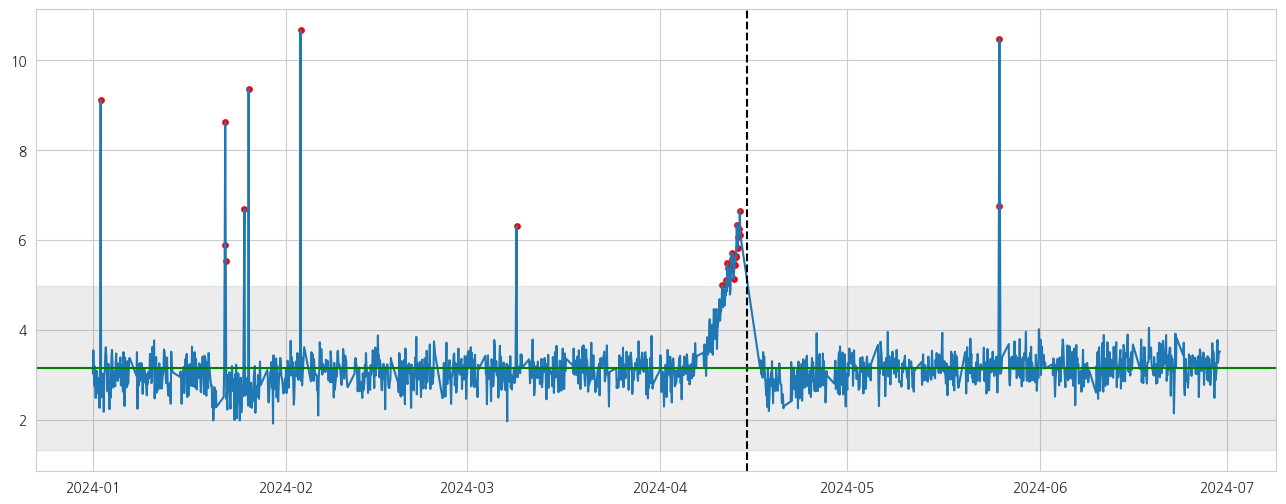

In [145]:
fig, ax = plt.subplots(figsize=(16,6))

ax.plot(eq_a03['timestamp'],eq_a03['vibration_mms'])
ax.scatter(eq_a03_vib.index,eq_a03_vib['vibration_mms'], color='red',s=15)
ax.axvline(pd.Timestamp('2024-04-15'), color= 'black', linestyle='--')
a03_mean=eq_a03['vibration_mms'].mean()
a03_std=eq_a03['vibration_mms'].std()
ax.axhline(a03_mean, color='green')
a03_mean-3*a03_std
ax.axhspan(a03_mean-3*a03_std,a03_mean+3*a03_std, color='gray', alpha=0.15)
plt.show()


In [137]:
a03_mean

np.float64(3.1442736960179474)

In [156]:
eq_a03.tail(3)

,sensor_id,equipment_id,temperature_c,vibration_mms,current_a,pressure_bar,date,month,hour,line,온도평균,온도표준편차,진동평균,진동표준편차,is_anomaly_temp,is_anomaly_vib
timestamp,,,,,,,,,,,,,,,,
2024-06-29 18:00:00,S-021717,EQ-A03,45.5,3.52,15.0,4.85,2024-06-29,6,18,A라인,45.494139,2.396841,3.144274,0.609298,False,False
2024-06-29 20:00:00,S-021729,EQ-A03,49.3,3.51,16.9,4.83,2024-06-29,6,20,A라인,45.494139,2.396841,3.144274,0.609298,False,False
2024-06-29 22:00:00,S-021741,EQ-A03,47.8,3.51,17.5,4.77,2024-06-29,6,22,A라인,45.494139,2.396841,3.144274,0.609298,False,False


In [153]:
eq_a03=eq_a03.set_index('timestamp').sort_index()

In [158]:
eq_a03['vib_means_1day']=eq_a03['vibration_mms'].rolling(window=12).mean()

In [160]:
eq_a03['vib_stds_1day']=eq_a03['vibration_mms'].rolling(window=12).std()

In [173]:
eq_a03['vib_means_1day_1diff']=eq_a03['vibration_mms'].diff().rolling(window=81).mean()

In [176]:
eq_a03['anomaly_24h']=(eq_a03['vibration_mms']<(eq_a03['vib_means_1day']-2*eq_a03['vib_stds_1day']))|(eq_a03['vibration_mms']>(eq_a03['vib_means_1day']+2*eq_a03['vib_stds_1day']))

In [177]:
eq_a03['anomaly_24h'].sum()

np.int64(64)

In [183]:
eq_a03_anoraml=eq_a03[eq_a03['anomaly_24h'] == True]

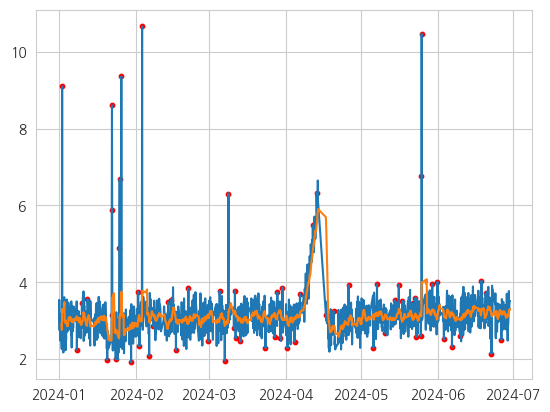

In [185]:
fig , ax = plt.subplots()

ax.plot(eq_a03.index, eq_a03['vibration_mms'])
ax.plot(eq_a03.index, eq_a03['vib_means_1day'])
ax.scatter(eq_a03_anoraml.index,eq_a03_anoraml['vibration_mms'],color='red',s=10)

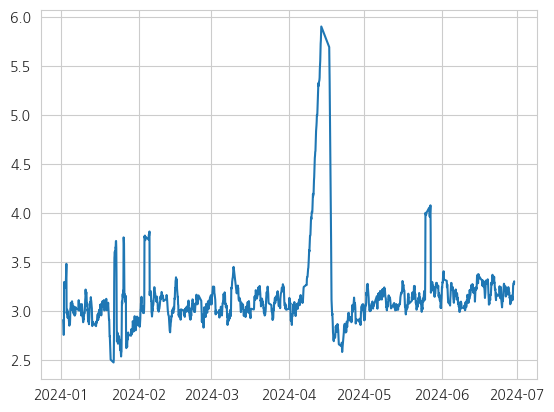

In [ ]:
plt.plot(eq_a03.index,eq_a03['vib_means_1day'])

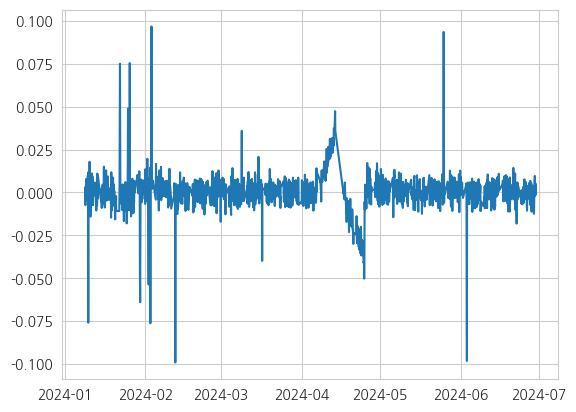

In [174]:
plt.plot(eq_a03.index,eq_a03['vib_means_1day_1diff'])

---
## Part 3: 고장 전조 패턴 분석 (20점)

이상탐지를 넘어, **고장 발생 전에 어떤 패턴이 나타나는지** 구체적으로 분석합니다.  
이 패턴을 알면 향후 고장을 예측할 수 있습니다.

> **현업 포인트**: 고장 전 10일 → 7일 → 3일 → 1일 시점의 센서값 변화를 추적하면  
> "몇 일 전부터 이상 징후가 나타나는지" 파악할 수 있습니다.

### 문제 3-1: 고장 전 센서 변화율 분석 (10점)

3건의 고장(EQ-A03 4/15, EQ-C02 5/20, EQ-A01 3/10)에 대해:

1. 고장 전 14일간의 **일별 평균 센서값**을 추출하세요
2. 정상 기간(고장 30일 전 ~ 15일 전) 대비 **변화율(%)**을 계산하세요
   - 변화율 = (고장전 값 - 정상기간 평균) / 정상기간 평균 × 100
3. 3건의 고장 각각에 대해 **고장 D-14 ~ D-0의 센서 변화율**을 라인 차트로 시각화
   - 1×3 서브플롯 (EQ-A03 진동, EQ-C02 온도, EQ-A01 전류)
   - x축: D-14, D-13, ..., D-1, D-0
   - y축: 변화율 (%)
4. 각 고장에서 **가장 먼저 10% 이상 변화**가 나타나는 시점(D-?)을 확인하세요

In [ ]:
# 여기에 코드 작성
eq_data=sensor[sensor['equipment_id']=='EQ-A03'].copy()

In [191]:
eq_data['date']=pd.to_datetime(eq_data['date'])

In [192]:
eq_data.columns

Index(['sensor_id', 'timestamp', 'equipment_id', 'temperature_c',
       'vibration_mms', 'current_a', 'pressure_bar', 'date', 'month', 'hour',
       'line', '온도평균', '온도표준편차', '진동평균', '진동표준편차', 'is_anomaly_temp',
       'is_anomaly_vib'],
      dtype='object')

In [194]:
daily=eq_data.groupby('date')['vibration_mms'].mean()

In [196]:
fail_date = pd.Timestamp('2024-04-15')

In [199]:
nomaly_start=fail_date - pd.Timedelta(days=30)

In [201]:
nomaly_end = fail_date  - pd.Timedelta(days=15)

In [205]:
normal_mean = daily[(daily.index >=  nomaly_start) &  (daily.index < nomaly_end)].mean()

In [206]:
normal_mean

np.float64(3.109666083916084)

In [211]:
pre_failure=daily[(daily.index <= fail_date) & (daily.index >= fail_date - pd.Timedelta(days=14))]

In [ ]:
change_rate =  

### 문제 3-2: 정비 이력과 센서 상관관계 (10점)

1. `maint` 테이블에서 CM(고장수리) 건만 필터링
2. 각 고장수리 발생일 **전 7일간**의 평균 센서값(온도, 진동)과  
   **평상시** 평균 센서값을 비교하는 표를 만드세요
3. 예방정비(PM) 전후 7일간의 센서값 변화도 비교하세요
   - PM 전 7일 평균 vs PM 후 7일 평균
   - **예방정비 효과**가 센서값으로 확인되는가?
4. **라인별 고장 건수**, **라인별 PM 건수**, **설비 나이**를 결합하여  
   PM을 잘 지킨 라인이 고장이 적은지 확인하세요

In [214]:
# 여기에 코드 작성
maint.loc[(maint['maintenance_type']=='PM')&(maint['equipment_id']=='EQ-A01'),'date']

14   2024-01-15
86   2024-03-12
Name: date, dtype: datetime64[ns]

In [216]:
sensor.columns

Index(['sensor_id', 'timestamp', 'equipment_id', 'temperature_c',
       'vibration_mms', 'current_a', 'pressure_bar', 'date', 'month', 'hour',
       'line', '온도평균', '온도표준편차', '진동평균', '진동표준편차', 'is_anomaly_temp',
       'is_anomaly_vib'],
      dtype='object')

In [226]:
sensor_daily=sensor[sensor['equipment_id']=='EQ-A01'].groupby('date')[['temperature_c',
       'vibration_mms', 'current_a', 'pressure_bar']].mean().copy()

In [227]:
sensor_daily

,temperature_c,vibration_mms,current_a,pressure_bar
date,,,,
2024-01-01,42.163636,2.515455,15.000000,5.156364
2024-01-02,42.350000,2.619000,15.270000,5.089000
2024-01-03,43.331818,2.541364,14.918182,5.077273
2024-01-04,43.200000,2.478750,15.616667,5.051667
2024-01-05,42.527273,2.405455,14.831818,4.920000
...,...,...,...,...
2024-06-25,44.716667,2.714583,14.508333,4.915833
2024-06-26,45.216667,2.792917,14.766667,4.901667
2024-06-27,45.325000,2.746667,15.237500,4.994167


In [228]:
sensor_daily.index=pd.to_datetime(sensor_daily.index)

In [230]:
sensor_daily.index

DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05', '2024-01-06', '2024-01-08', '2024-01-09',
               '2024-01-10', '2024-01-11',
               ...
               '2024-06-19', '2024-06-20', '2024-06-21', '2024-06-22',
               '2024-06-24', '2024-06-25', '2024-06-26', '2024-06-27',
               '2024-06-28', '2024-06-29'],
              dtype='datetime64[ns]', name='date', length=155, freq=None)

In [235]:
df1=sensor_daily.loc[pd.Timestamp('2024-01-15')-pd.Timedelta(days=7): '2024-01-15',].reset_index(drop=True)

In [236]:
df1.columns =['전 온도','전 진동','전 전류','전 압력']

In [237]:
df1

,전 온도,전 진동,전 전류,전 압력
0,42.420833,2.504583,15.200000,4.978333
1,42.216667,2.541667,14.858333,5.027500
2,42.208333,2.545833,14.933333,5.062500
3,43.383333,2.531667,14.750000,4.978333
4,42.016667,2.423333,14.625000,4.955000
5,42.866667,2.500833,15.516667,4.984167
6,40.627273,2.060000,15.127273,5.049091


In [239]:
df2=sensor_daily.loc['2024-01-15':pd.Timestamp('2024-01-15')+pd.Timedelta(days=7),].reset_index(drop=True)

In [241]:
df2.columns =['후 온도','후 진동','후 전류','후 압력']

In [242]:
df2

,후 온도,후 진동,후 전류,후 압력
0,40.627273,2.060000,15.127273,5.049091
1,40.641667,2.040833,14.991667,4.960000
2,41.508333,2.073333,15.058333,5.029167
3,41.500000,2.144545,15.436364,5.096364
4,42.758333,2.275000,15.016667,4.975833
5,41.316667,2.142500,14.900000,4.998333
6,41.390909,2.219091,15.390909,5.005455


In [244]:
df=pd.concat([df1,df2],axis=1)

In [245]:
df[['전 온도', '후 온도']]

,전 온도,후 온도
0,42.420833,40.627273
1,42.216667,40.641667
2,42.208333,41.508333
3,43.383333,41.500000
4,42.016667,42.758333
5,42.866667,41.316667
6,40.627273,41.390909


In [252]:
df['온도차이']=df['전 온도']-df['후 온도']

In [253]:
df

,전 온도,전 진동,전 전류,전 압력,후 온도,후 진동,후 전류,후 압력,온도차이
0,42.420833,2.504583,15.200000,4.978333,40.627273,2.060000,15.127273,5.049091,1.793561
1,42.216667,2.541667,14.858333,5.027500,40.641667,2.040833,14.991667,4.960000,1.575000
2,42.208333,2.545833,14.933333,5.062500,41.508333,2.073333,15.058333,5.029167,0.700000
3,43.383333,2.531667,14.750000,4.978333,41.500000,2.144545,15.436364,5.096364,1.883333
4,42.016667,2.423333,14.625000,4.955000,42.758333,2.275000,15.016667,4.975833,-0.741667
5,42.866667,2.500833,15.516667,4.984167,41.316667,2.142500,14.900000,4.998333,1.550000
6,40.627273,2.060000,15.127273,5.049091,41.390909,2.219091,15.390909,5.005455,-0.763636


In [254]:
df['진동차이']=df['전 진동']-df['후 진동']

In [255]:
df['전류차이']=df['전 전류']-df['후 전류']

In [256]:
df['압력차이']=df['전 압력']-df['후 압력']

In [257]:
df

,전 온도,전 진동,전 전류,전 압력,후 온도,후 진동,후 전류,후 압력,온도차이,진동차이,전류차이,압력차이
0,42.420833,2.504583,15.200000,4.978333,40.627273,2.060000,15.127273,5.049091,1.793561,0.444583,0.072727,-0.070758
1,42.216667,2.541667,14.858333,5.027500,40.641667,2.040833,14.991667,4.960000,1.575000,0.500833,-0.133333,0.067500
2,42.208333,2.545833,14.933333,5.062500,41.508333,2.073333,15.058333,5.029167,0.700000,0.472500,-0.125000,0.033333
3,43.383333,2.531667,14.750000,4.978333,41.500000,2.144545,15.436364,5.096364,1.883333,0.387121,-0.686364,-0.118030
4,42.016667,2.423333,14.625000,4.955000,42.758333,2.275000,15.016667,4.975833,-0.741667,0.148333,-0.391667,-0.020833
5,42.866667,2.500833,15.516667,4.984167,41.316667,2.142500,14.900000,4.998333,1.550000,0.358333,0.616667,-0.014167
6,40.627273,2.060000,15.127273,5.049091,41.390909,2.219091,15.390909,5.005455,-0.763636,-0.159091,-0.263636,0.043636


In [258]:
maint

,maintenance_id,date,equipment_id,maintenance_type,description,cause,duration_hours,cost_won,parts_replaced,technician_id
0,MT-00001,2024-01-01,EQ-A02,INS,주간점검 - 일상점검,일상점검,1.0,14000,NaN,TECH-08
1,MT-00002,2024-01-01,EQ-B01,INS,주간점검 - 진동측정,진동측정,1.0,24000,NaN,TECH-01
2,MT-00003,2024-01-01,EQ-C01,INS,주간점검 - 온도측정,온도측정,2.0,42000,NaN,TECH-07
3,MT-00004,2024-01-03,EQ-C02,BM,사후보전 - 소모품교체,소모품교체,3.0,105000,베어링,TECH-07
4,MT-00005,2024-01-04,EQ-C03,CM,고장수리 - 모터과열,모터과열,46.0,1237000,NaN,TECH-04
...,...,...,...,...,...,...,...,...,...,...
225,MT-00226,2024-06-24,EQ-C03,INS,주간점검 - 진동측정,진동측정,2.0,37000,NaN,TECH-02
226,MT-00227,2024-06-25,EQ-A01,BM,사후보전 - 윤활,윤활,2.0,144000,베어링,TECH-03
227,MT-00228,2024-06-25,EQ-C02,BM,사후보전 - 볼트조임,볼트조임,2.0,37000,오일,TECH-08
228,MT-00229,2024-06-28,EQ-A03,CM,고장수리 - 냉각계통이상,냉각계통이상,23.0,424000,NaN,TECH-06


In [261]:
main_line= pd.merge(maint,equip,on = 'equipment_id',how='left')

In [262]:
main_line

,maintenance_id,date,equipment_id,maintenance_type,description,cause,duration_hours,cost_won,parts_replaced,technician_id,equipment_name,line,equipment_type,install_date,cumulative_hours,pm_cycle_days,last_pm_date,criticality,age_years
0,MT-00001,2024-01-01,EQ-A02,INS,주간점검 - 일상점검,일상점검,1.0,14000,NaN,TECH-08,CNC선반-A2,A라인,CNC선반,2018-06-20,12100,90,2024-02-01,B,6.0
1,MT-00002,2024-01-01,EQ-B01,INS,주간점검 - 진동측정,진동측정,1.0,24000,NaN,TECH-01,CNC선반-B1,B라인,CNC선반,2021-07-01,5800,90,2024-02-15,B,3.0
2,MT-00003,2024-01-01,EQ-C01,INS,주간점검 - 온도측정,온도측정,2.0,42000,NaN,TECH-07,CNC선반-C1,C라인,CNC선반,2020-01-15,8500,90,2024-01-10,B,4.5
3,MT-00004,2024-01-03,EQ-C02,BM,사후보전 - 소모품교체,소모품교체,3.0,105000,베어링,TECH-07,CNC선반-C2,C라인,CNC선반,2020-04-10,8200,90,2024-02-05,A,4.2
4,MT-00005,2024-01-04,EQ-C03,CM,고장수리 - 모터과열,모터과열,46.0,1237000,NaN,TECH-04,밀링머신-C3,C라인,밀링머신,2020-08-25,7100,60,2024-02-10,B,3.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,MT-00226,2024-06-24,EQ-C03,INS,주간점검 - 진동측정,진동측정,2.0,37000,NaN,TECH-02,밀링머신-C3,C라인,밀링머신,2020-08-25,7100,60,2024-02-10,B,3.9
226,MT-00227,2024-06-25,EQ-A01,BM,사후보전 - 윤활,윤활,2.0,144000,베어링,TECH-03,CNC선반-A1,A라인,CNC선반,2018-03-15,12500,90,2024-01-15,A,6.3
227,MT-00228,2024-06-25,EQ-C02,BM,사후보전 - 볼트조임,볼트조임,2.0,37000,오일,TECH-08,CNC선반-C2,C라인,CNC선반,2020-04-10,8200,90,2024-02-05,A,4.2
228,MT-00229,2024-06-28,EQ-A03,CM,고장수리 - 냉각계통이상,냉각계통이상,23.0,424000,NaN,TECH-06,밀링머신-A3,A라인,밀링머신,2019-01-10,10800,60,2024-01-20,A,5.5


In [263]:
main_line.loc[main_line['maintenance_type']=='CM',]

,maintenance_id,date,equipment_id,maintenance_type,description,cause,duration_hours,cost_won,parts_replaced,technician_id,equipment_name,line,equipment_type,install_date,cumulative_hours,pm_cycle_days,last_pm_date,criticality,age_years
4,MT-00005,2024-01-04,EQ-C03,CM,고장수리 - 모터과열,모터과열,46.0,1237000,NaN,TECH-04,밀링머신-C3,C라인,밀링머신,2020-08-25,7100,60,2024-02-10,B,3.9
13,MT-00014,2024-01-13,EQ-B04,CM,고장수리 - 유압누유,유압누유,42.0,1613000,볼트,TECH-06,드릴프레스-B4,B라인,드릴프레스,2022-05-20,3900,120,2024-01-25,C,2.1
21,MT-00022,2024-01-16,EQ-A04,CM,고장수리 - 센서고장,센서고장,15.0,1423000,필터,TECH-05,드릴프레스-A4,A라인,드릴프레스,2019-04-05,10200,120,2023-12-10,C,5.2
47,MT-00048,2024-02-14,EQ-A04,CM,고장수리 - 모터과열,모터과열,46.0,1057000,필터,TECH-05,드릴프레스-A4,A라인,드릴프레스,2019-04-05,10200,120,2023-12-10,C,5.2
67,MT-00068,2024-02-27,EQ-A02,CM,고장수리 - 냉각계통이상,냉각계통이상,10.0,418000,볼트,TECH-03,CNC선반-A2,A라인,CNC선반,2018-06-20,12100,90,2024-02-01,B,6.0
78,MT-00079,2024-03-06,EQ-A01,CM,고장수리 - 센서고장,센서고장,43.0,1132000,오일,TECH-08,CNC선반-A1,A라인,CNC선반,2018-03-15,12500,90,2024-01-15,A,6.3
97,MT-00098,2024-03-21,EQ-A01,CM,고장수리 - 기어손상,기어손상,25.0,256000,필터,TECH-01,CNC선반-A1,A라인,CNC선반,2018-03-15,12500,90,2024-01-15,A,6.3
113,MT-00114,2024-04-05,EQ-A03,CM,고장수리 - 전기접촉불량,전기접촉불량,12.0,1915000,필터,TECH-06,밀링머신-A3,A라인,밀링머신,2019-01-10,10800,60,2024-01-20,A,5.5
114,MT-00115,2024-04-05,EQ-B02,CM,고장수리 - 스핀들이상,스핀들이상,16.0,1026000,베어링,TECH-04,CNC선반-B2,B라인,CNC선반,2021-09-15,5500,90,2024-02-20,B,2.8
126,MT-00127,2024-04-15,EQ-A03,CM,고장수리 - 냉각계통이상,냉각계통이상,18.0,1400000,씰,TECH-08,밀링머신-A3,A라인,밀링머신,2019-01-10,10800,60,2024-01-20,A,5.5


---
## Part 4: 설비 건강도 스코어링 (20점)

개별 센서 분석을 넘어, 설비의 **종합적인 건강 상태**를 점수화합니다.  
이를 통해 어떤 설비를 우선 정비해야 하는지 의사결정할 수 있습니다.

> **현업 포인트**: 설비 건강도 = f(센서 상태, 가동시간, 정비이력, 알람빈도)

### 문제 4-1: 설비 건강도 지표 설계 (10점)

다음 5가지 지표로 설비 건강도를 계산하세요 (각 지표 0~100점 정규화):

| 지표 | 계산 방법 | 가중치 |
|------|----------|--------|
| 센서 이상 점수 | 최근 30일 이상치 비율 (낮을수록 좋음) | 30% |
| 진동 수준 점수 | 최근 30일 평균 진동 (낮을수록 좋음) | 25% |
| 정비 이행률 | PM 건수 / 예정 PM 건수 (높을수록 좋음) | 20% |
| 고장 빈도 점수 | CM 건수 (적을수록 좋음) | 15% |
| 알람 빈도 점수 | 알람 건수 (적을수록 좋음) | 10% |

1. 각 지표를 0~100으로 정규화하세요 (min-max 또는 순위 기반)
   - 100점 = 최상 상태, 0점 = 최악 상태
2. 가중 평균으로 **종합 건강도 점수**를 계산
3. 설비별 건강도를 표로 출력 (내림차순)
4. 건강도 점수별 등급 부여:
   - A등급(80+), B등급(60~80), C등급(40~60), D등급(40 미만)

In [89]:
# 여기에 코드 작성


### 문제 4-2: 설비 건강도 대시보드 (10점)

**2행 2열 (4패널)** 대시보드를 만드세요. Figure 크기: (16, 12)

| 위치 | 차트 | 내용 |
|------|------|------|
| (1,1) | 수평 바 차트 | 설비별 건강도 점수 (등급별 색상) |
| (1,2) | 히트맵 | 설비 × 5개 지표 점수 매트릭스 |
| (2,1) | 라인 차트 | 고장 설비(EQ-A03) 진동 시계열 + 이동평균 + 고장일 |
| (2,2) | 산점도 | 설비 나이 vs 건강도 점수 (크기=누적가동시간) |

전체 제목: '설비 건강도 모니터링 대시보드 (2024년 6월 기준)'

In [90]:
# 여기에 코드 작성


---
## Part 5: 예지보전 전략 제안 (15점)

### 문제 5-1: 종합 분석 및 전략 제안 (15점)

분석 결과를 바탕으로 아래 항목을 **마크다운 셀에** 작성하세요.

1. **현재 설비 상태 요약**: 건강도 등급별 설비 분포
2. **고장 전조 패턴**: 어떤 센서가, 몇 일 전부터 변화하는가?
3. **이상탐지 방법 비교**: 3-Sigma vs 이동평균 기반, 각각의 장단점
4. **예방정비 효과**: PM이 센서값과 고장빈도에 미치는 영향
5. **우선 조치 대상 설비**: 건강도 기준 하위 3대 설비와 조치 방안
6. **예지보전 시스템 제안**:
   - 어떤 센서를 우선 모니터링할 것인가?
   - 알람 임계값은 어떻게 설정할 것인가?
   - PM 주기를 어떻게 최적화할 것인가?

### 분석 결론 (여기에 작성)

1. **현재 설비 상태 요약**: 

2. **고장 전조 패턴**: 

3. **이상탐지 방법 비교**: 

4. **예방정비 효과**: 

5. **우선 조치 대상**: 

6. **예지보전 시스템 제안**: 


---
## 수고하셨습니다!

### 학습 체크리스트
- [ ] 시계열 센서 데이터 보간(interpolation) 처리
- [ ] 설비별 센서 기본 통계 비교
- [ ] 이동평균과 시계열 시각화
- [ ] 3-Sigma 이상탐지 구현 및 시각화
- [ ] 이동평균 기반 동적 이상탐지
- [ ] 고장 전조 패턴 (D-14 ~ D-0) 변화율 분석
- [ ] 정비 이력과 센서 데이터 연계 분석
- [ ] 설비 건강도 스코어링 설계 및 계산
- [ ] 4패널 대시보드 구성
- [ ] 데이터 기반 예지보전 전략 제안